In [2]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis import distances

KeyboardInterrupt: 

In [2]:
u = mda.Universe("freeze.pdb", format="PDB")

C:\Users\ulast\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\MDAnalysis\topology\PDBParser.py:372: UserWarning: Unknown element EP found for some atoms. These have been given an empty element record. If needed they can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn(wmsg)


In [3]:
O = u.select_atoms("name O")
H = u.select_atoms("name H1 H2")

In [4]:
from openmm.app import *
from openmm.unit import *
from openmm import Vec3

modeller = Modeller(Topology(), [])

forcefield = ForceField("tip3p.xml")

modeller.addSolvent(
    forcefield,
    model="tip3p",
    boxSize=Vec3(3.0, 3.0, 3.0)*nanometer
)

with open("water_tip3p.pdb", "w") as f:
    PDBFile.writeFile(modeller.topology, modeller.positions, f)

print("water_tip3p.pdb created")

water_tip3p.pdb created


Geometria molekularna (O–H, kąt H–O–H)  
Długości O–H

In [4]:
r_OH = []

for ts in u.trajectory:
    for res in u.residues:
        O_atom = res.atoms.select_atoms("name O")
        H_atoms = res.atoms.select_atoms("name H1 H2")
        if len(O_atom) == 1 and len(H_atoms) == 2:
            for H_atom in H_atoms:
                r = np.linalg.norm(H_atom.position - O_atom.positions[0])
                r_OH.append(r)

r_OH = np.array(r_OH)


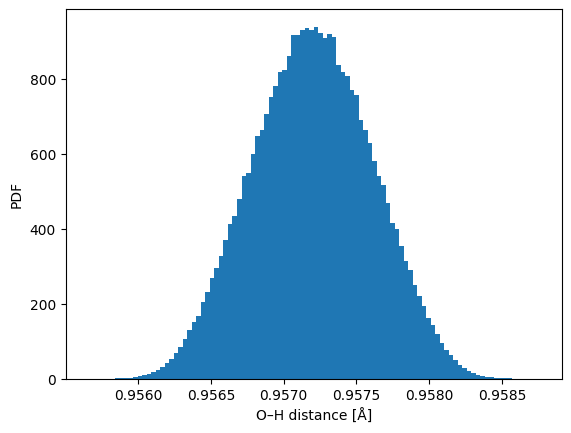

In [5]:
plt.hist(r_OH, bins=100, density=True)
plt.xlabel("O–H distance [Å]")
plt.ylabel("PDF")
plt.show()

In [6]:
def angle(a, b, c):
    ba = a - b
    bc = c - b
    cosang = np.dot(ba, bc) / (np.linalg.norm(ba)*np.linalg.norm(bc))
    return np.degrees(np.arccos(cosang))

angles = []

for ts in u.trajectory:
    for res in u.residues:
        atoms = res.atoms
        if len(atoms.select_atoms("name O")) == 1:
            Oa = atoms.select_atoms("name O")[0]
            Hs = atoms.select_atoms("name H1 H2")
            if len(Hs) == 2:
                angles.append(angle(Hs[0].position, Oa.position, Hs[1].position))

angles = np.array(angles)


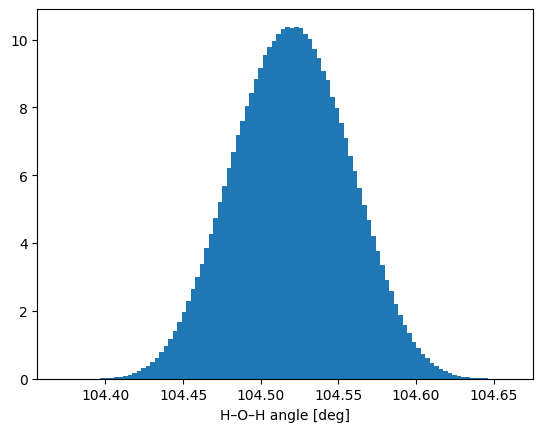

In [7]:
plt.hist(angles, bins=100, density=True)
plt.xlabel("H–O–H angle [deg]")
plt.show()


Sieć wiązań wodorowych (H-bonds)

In [8]:
def is_hbond(Oi, Hi, Oj):
    r_OO = np.linalg.norm(Oi - Oj)
    if r_OO > 3.5:
        return False
    ang = angle(Oi, Hi, Oj)
    return ang > 150


In [9]:
hbonds_per_frame = []

for ts in u.trajectory:
    hb_count = 0
    for res_i in u.residues:
        Oi = res_i.atoms.select_atoms("name O")
        Hi = res_i.atoms.select_atoms("name H1 H2")
        if len(Oi) != 1:
            continue
        for res_j in u.residues:
            if res_i == res_j:
                continue
            Oj = res_j.atoms.select_atoms("name O")
            if len(Oj) != 1:
                continue
            for H in Hi:
                if is_hbond(Oi.positions[0], H.position, Oj.positions[0]):
                    hb_count += 1
    hbonds_per_frame.append(hb_count / len(u.residues))


KeyboardInterrupt: 

In [10]:
from MDAnalysis.analysis.rdf import InterRDF

rdf = InterRDF(O, O, range=(0.0, 10.0))
rdf.run()


C:\Users\ulast\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\MDAnalysis\analysis\base.py:562: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


ZeroDivisionError: float division by zero